# Information Diffusion and Market Reaction: Meta Platforms Q4 FY2021 Earnings

This notebook is an **exploratory walkthrough** of the SignalFlow research pipeline. It calls the
same reusable, tested code that powers the FastAPI backend and the dashboard
(`src/signalflow/`) -- nothing here re-implements the analysis; the notebook only
loads, calls, and visualizes it.

**Research question:** How does newly released earnings information become incorporated into a
company's stock price, and how do the timing and intensity of news coverage relate to the speed
and magnitude of the market reaction?

**Event:** Meta Platforms, Inc. (META) Q4 FY2021 earnings, announced after market close on
2022-02-02. See `docs/research_report.md` for the full write-up and `data/README.md` for the
data provenance of every input file.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from signalflow import config, diffusion, earnings, event_study, hypotheses, sentiment
from signalflow.data import load_earnings_facts, load_news_headlines, load_price_series, merge_price_series

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Load the real, raw data

In [2]:
company_prices = load_price_series(config.META_PRICES_CSV)
benchmark_prices = load_price_series(config.BENCHMARK_PRICES_CSV)
facts = load_earnings_facts(config.EARNINGS_FACTS_JSON)
news_df = load_news_headlines(config.NEWS_HEADLINES_CSV)

print(f"META price rows: {len(company_prices)}  ({company_prices['date'].min().date()} to {company_prices['date'].max().date()})")
print(f"Benchmark (S&P 500) price rows: {len(benchmark_prices)}")
print(f"News headlines: {len(news_df)}")
company_prices.tail()


META price rows: 222  (2021-06-01 to 2022-04-14)
Benchmark (S&P 500) price rows: 222
News headlines: 13


,date,open,high,low,close,adj_close,volume
217,2022-04-08,222.380005,225.130005,220.029999,222.330002,220.394592,18375700
218,2022-04-11,218.419998,220.610001,215.220001,216.460007,214.575729,20516600
219,2022-04-12,220.240005,222.029999,213.130005,214.139999,212.275894,20128800
220,2022-04-13,211.820007,216.610001,211.330002,214.990005,213.118469,19231800
221,2022-04-14,214.889999,214.990005,210.000000,210.179993,208.350327,18379500


## 2. Price and volume around the event\n\nThe February 3, 2022 crash is visible directly in the raw, unmodified closing price and volume series.

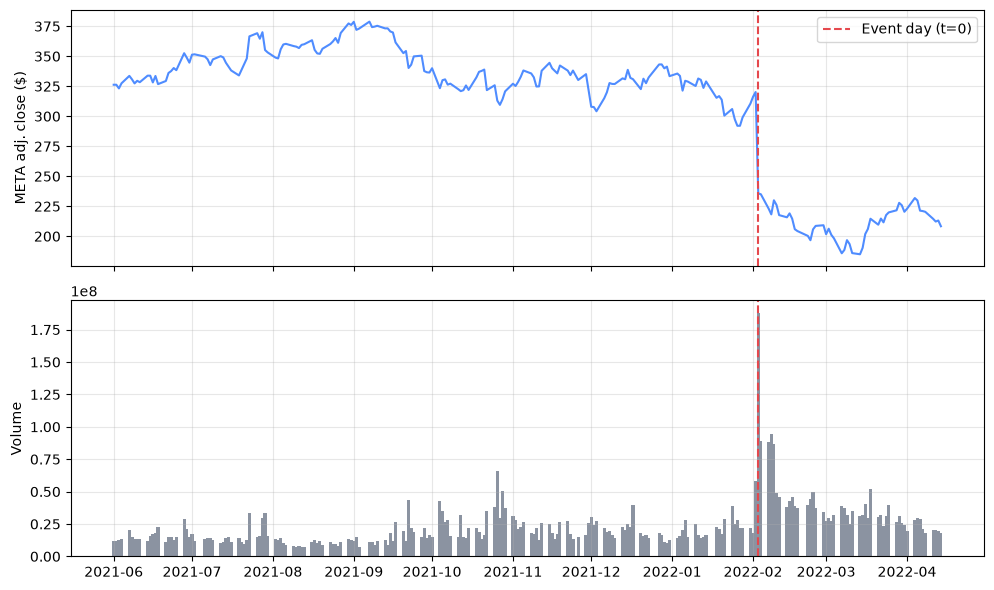

In [3]:
event_day = pd.Timestamp(config.DEFAULT_EVENT.event_day)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
axes[0].plot(company_prices["date"], company_prices["adj_close"], color="#4f8cff")
axes[0].axvline(event_day, color="#e5484d", linestyle="--", label="Event day (t=0)")
axes[0].set_ylabel("META adj. close ($)")
axes[0].legend()

axes[1].bar(company_prices["date"], company_prices["volume"], color="#8b93a1", width=1.2)
axes[1].axvline(event_day, color="#e5484d", linestyle="--")
axes[1].set_ylabel("Volume")
plt.tight_layout()
plt.show()


## 3. Earnings surprise (real, reported figures)

In [4]:
earnings_summary = earnings.summarize_surprise(facts)
for key, value in earnings_summary.items():
    print(f"{key:28s} {value}")


eps_actual                   3.67
eps_estimate                 3.84
eps_surprise_pct             -4.4271
revenue_actual_usd_billion   33.67
revenue_estimate_usd_billion 33.4
revenue_surprise_pct         0.8084
direction                    miss


## 4. Event study: market-model abnormal returns

Market-model parameters (alpha, beta) are estimated on a 120-trading-day window ending 10 days
before the event (see `src/signalflow/config.py` for the full justification), then used to compute
the abnormal return the company earned *beyond* what its historical relationship with the S&P 500
would predict.


In [5]:
merged = merge_price_series(company_prices, benchmark_prices)
study = event_study.run_event_study(merged, config.DEFAULT_EVENT)

print("Market model:", study["market_model"])
print()
print("Summary:")
for key, value in study["summary"].items():
    print(f"  {key}: {value}")


Market model: {'alpha': -0.0011104864850672701, 'beta': 1.3075494214045245, 'resid_std': 0.014550576595085104, 'n_obs': 120, 'r_squared': 0.35893536039394264, 'estimation_window': [-130, -10]}

Summary:
  car_full_window: -0.29435271765990356
  mean_pre_event_return: 0.018634754102879382
  mean_post_event_return: -0.013006132599699826
  volatility_pre_event: 0.01412424221812451
  volatility_post_event: 0.030428600711503866
  volatility_estimation_window: 0.01809659284058945
  max_abs_abnormal_return: {'relative_day': 0, 'date': '2022-02-03', 'value': -0.230897915356573}
  max_abs_cumulative_abnormal_return: {'relative_day': 10, 'date': '2022-02-17', 'value': -0.29435271765990356}
  event_day_abnormal_return: -0.230897915356573
  event_day_t_stat: -15.868643682104373
  event_day_p_value: 0.0
  event_day_abnormal_volume_ratio: 9.93516726015955


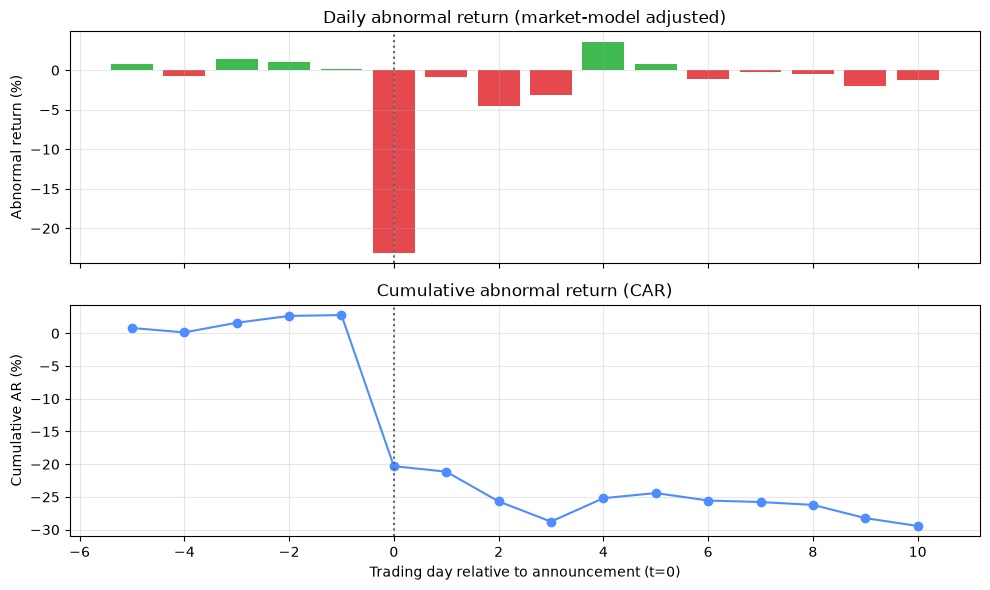

In [6]:
daily = pd.DataFrame(study["daily"]).sort_values("relative_day")

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
colors = ["#3fb950" if v >= 0 else "#e5484d" for v in daily["abnormal_return"]]
axes[0].bar(daily["relative_day"], daily["abnormal_return"] * 100, color=colors)
axes[0].axvline(0, color="#5b6472", linestyle=":")
axes[0].set_ylabel("Abnormal return (%)")
axes[0].set_title("Daily abnormal return (market-model adjusted)")

axes[1].plot(daily["relative_day"], daily["cumulative_abnormal_return"] * 100, marker="o", color="#4f8cff")
axes[1].axvline(0, color="#5b6472", linestyle=":")
axes[1].set_ylabel("Cumulative AR (%)")
axes[1].set_xlabel("Trading day relative to announcement (t=0)")
axes[1].set_title("Cumulative abnormal return (CAR)")
plt.tight_layout()
plt.show()


## 5. News sentiment and information intensity\n\nVADER sentiment scores computed directly on the 13 real, curated headlines in `data/raw/news_headlines.csv`.

In [7]:
scored_news = sentiment.score_headlines(news_df)
info_intensity = sentiment.daily_information_intensity(scored_news)
scored_news[["date", "source", "headline", "sentiment_compound", "sentiment_label"]]


,date,source,headline,sentiment_compound,sentiment_label
0,2022-01-27,The Motley Fool,Meta Platforms Q4 Earnings Preview: Look for I...,0.2732,positive
1,2022-01-31,FXStreet,Meta (FB) Stock: Q4 2021 Earnings Report Preview,0.0000,neutral
2,2022-02-02,CNBC,Facebook-parent Meta (FB) Q4 2021 earnings,0.0000,neutral
3,2022-02-02,CNBC Now (X/Twitter),EARNINGS: Meta Platforms Q4 EPS $3.67 vs. $3.8...,0.0000,neutral
4,2022-02-02,The Washington Post,Facebook loses users for first time in history,-0.3182,negative
5,2022-02-03,The Motley Fool,Meta Platforms (FB) Q4 2021 Earnings Call Tran...,0.0000,neutral
6,2022-02-03,CNBC,Facebook stock plummets 26% in its biggest one...,-0.7579,negative
7,2022-02-03,Bloomberg,"Meta (FB) Set for $200 Billion Wipeout, Among ...",-0.8519,negative
8,2022-02-03,Forbes,Facebook Loses Daily Active Users For The Firs...,0.1027,positive
9,2022-02-03,OPB / Associated Press,"Meta, formerly Facebook, faces historic drop a...",-0.6908,negative


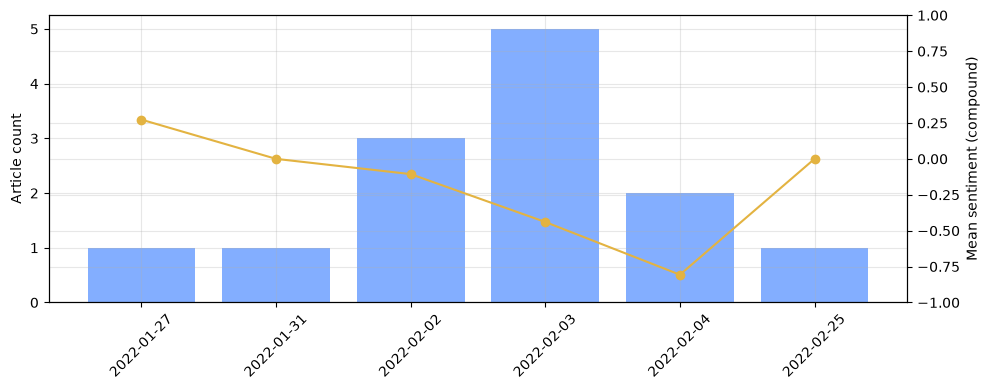

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(info_intensity["date_str"], info_intensity["article_count"], color="#4f8cff", alpha=0.7, label="Article count")
ax1.set_ylabel("Article count")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(info_intensity["date_str"], info_intensity["mean_sentiment"], color="#e3b341", marker="o", label="Mean sentiment")
ax2.set_ylabel("Mean sentiment (compound)")
ax2.set_ylim(-1, 1)
fig.tight_layout()
plt.show()


## 6. Information diffusion models

We fit two candidate curves -- exponential absorption and logistic diffusion -- to the fraction of
the eventual cumulative abnormal return absorbed on each post-event trading day, and compare them
with RMSE/MAE/R^2.


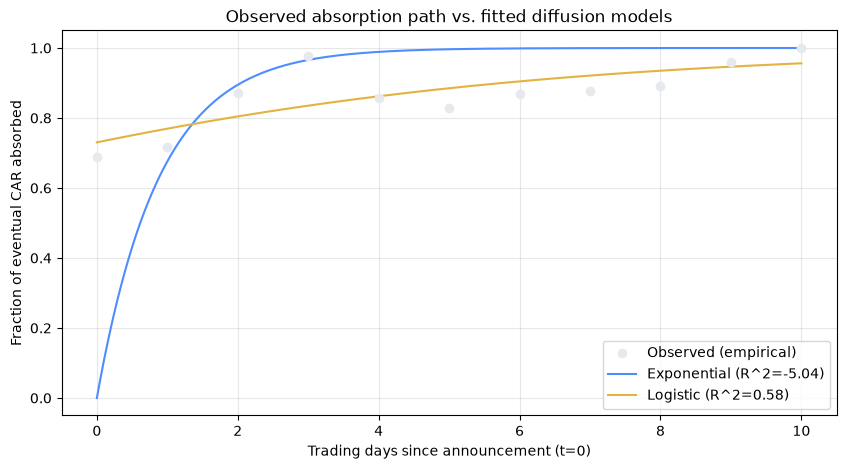

Better-fitting model: logistic
Information absorption time (trading days): {'p50': 0.0, 'p75': 1.20602385414076, 'p90': 2.261729975322584}


In [9]:
diffusion_comparison = diffusion.compare_diffusion_models(study["daily"], config.ABSORPTION_THRESHOLDS)

observed = diffusion_comparison["observed"]
t = np.array(observed["relative_day"])
fraction = np.array(observed["absorption_fraction"])
smooth_t = np.linspace(t.min(), t.max(), 200)

plt.figure(figsize=(10, 5))
plt.scatter(t, fraction, color="#e6e9ee", zorder=3, label="Observed (empirical)")

exp_fit = diffusion_comparison["models"]["exponential"]
if exp_fit["converged"]:
    plt.plot(smooth_t, diffusion.exponential_absorption(smooth_t, exp_fit["k"]), color="#4f8cff",
              label=f"Exponential (R^2={exp_fit['r_squared']:.2f})")

log_fit = diffusion_comparison["models"]["logistic"]
if log_fit["converged"]:
    plt.plot(smooth_t, diffusion.logistic_diffusion(smooth_t, log_fit["k"], log_fit["t0"]), color="#e3b341",
              label=f"Logistic (R^2={log_fit['r_squared']:.2f})")

plt.xlabel("Trading days since announcement (t=0)")
plt.ylabel("Fraction of eventual CAR absorbed")
plt.legend()
plt.title("Observed absorption path vs. fitted diffusion models")
plt.show()

print("Better-fitting model:", diffusion_comparison["better_fit_model"])
print("Information absorption time (trading days):", diffusion_comparison["information_absorption_time_trading_days"])


## 7. Hypothesis testing

In [10]:
event_df = pd.DataFrame(study["daily"])
hypothesis_results = hypotheses.run_all_hypotheses(
    earnings_summary, study["summary"], event_df, info_intensity, diffusion_comparison
)

for h in hypothesis_results:
    print(f"[{h['hypothesis']}] {'SUPPORTED' if h['supported'] else 'NOT SUPPORTED'} -- {h['statement']}")
    print(f"    {h['conclusion']}\n")


[H1] SUPPORTED -- A large earnings-related surprise is associated with a large, statistically significant abnormal return on the event day.
    The event-day abnormal return (-23.09%) is statistically significant at the 5% level (t=-15.87, p=0.0000). Notably the EPS surprise was small and negative (-4.43%) while revenue was a small beat (0.81%); the huge abnormal return is far larger than either surprise alone would suggest, indicating the market was reacting primarily to forward guidance and the first-ever DAU decline rather than to the earnings/revenue surprise in isolation. With a single event we cannot test whether *larger* surprises produce *proportionally larger* reactions -- that requires a cross-sectional sample of many earnings events, which is out of scope here.

[H2] SUPPORTED -- Increased news intensity is associated with increased trading volume.
    Pearson r = 0.67 (p=0.004) across 16 event-window trading days, only 5 of which have a curated headline. This sample is far 

## Next steps

This notebook only *demonstrates* the pipeline. For:
- the full methodology and literature grounding, see `docs/research_report.md`;
- the production implementation, see `src/signalflow/`;
- the interactive dashboard, run the backend (`uvicorn app.main:app`, from `backend/`) and the
  frontend (`npm run dev`, from `frontend/`) as described in the top-level `README.md`.
